## **Resumen del Caso de Estudio: Análisis de Retención de Clientes (Churn)**

### **1. Contexto y Problemática**
El proyecto se sitúa en una empresa de **servicios digitales por suscripción** que, a pesar de mantener un crecimiento sostenido, ha detectado una señal de alerta: el **aumento en la tasa de abandono (churn)** de clientes.

**Puntos Clave del Negocio:**
* **Eficiencia de Costos:** El área de negocio reconoce que es significativamente más económico **retener a un cliente actual** que adquirir uno nuevo.
* **Estrategia Preventiva:** El objetivo no es solo reaccionar al abandono, sino utilizar los datos para **anticipar comportamientos** y diseñar acciones preventivas.
* **Meta Final:** Desarrollar modelos predictivos que apoyen la toma de decisiones estratégicas para reducir la cancelación de servicios.

### **2. Análisis del Dataset y Variables**
El conjunto de datos entregado es multidimensional y requiere un tratamiento específico debido a la naturaleza de sus variables:

#### **A. Perfil Demográfico y de Registro**
* **Identificación:** `id_cliente` (con riesgo de duplicados) y `fecha_registro`.
* **Atributos:** `edad`, `genero`, `region`, `estado_civil` y `codigo_postal`. Estos permiten segmentar el comportamiento según el perfil del usuario.

#### **B. Situación Económica (Variables Críticas)**
Estas variables son fundamentales para entender la capacidad de pago y el riesgo de cancelación:
* **Ingresos y Gastos:** `ingreso_mensual` y `gasto_mensual` (este último presenta **valores nulos** que requieren imputación).
* **Carga Financiera:** `deuda_total` (con advertencia de **valores extremos outliers**) y `score_crediticio`.
* **Tenencia:** `tiene_tarjeta_credito` (variable binaria).

#### **C. Comportamiento y Uso del Servicio**
* **Fidelidad:** `antiguedad_meses`, `frecuencia_compra` y `ultima_compra_dias`.
* **Engagement:** `uso_app` (Alto, Medio, Bajo) y `num_productos` contratados.
* **Producto:** `tipo_plan` (Básico, Estándar, Premium).

#### **D. Variable Objetivo**
* **`abandono` (Churn):** Indicador binario (0 o 1) que señala si el cliente canceló el servicio. Este es el "norte" de todo el análisis de preprocesamiento realizado en este código.

### **3. Desafíos Técnicos Identificados**
Para asegurar la integridad del análisis, el flujo de código aborda:
1. **Limpieza de duplicados** en identificadores únicos.
2. **Tratamiento de nulos** en métricas de gasto.
3. **Gestión de outliers** en la deuda total para evitar sesgos en el modelo.
4. **Codificación de variables categóricas** (nominales y ordinales) para su procesamiento matemático.

# Librerias necesarias para el analisis de datos

In [67]:
"""
Este bloque carga todas las librerías necesarias para la auditoría, análisis exploratorio
y preprocesamiento de datos del modelo predictivo.

Utilidad de las librerías por bloque lógico:

1. Manejo de Estructuras y Matemáticas:
   - pandas (pd): Fundamental para la ingesta, manipulación y transformación de
     datos tabulares (DataFrames y Series).
   - numpy (np): Motor de cálculo numérico eficiente; utilizado para operaciones
     algebraicas, condicionales (np.where) y manejo nativo de valores nulos (NaN).

2. Visualización de Datos:
   - matplotlib.pyplot (plt): Librería base para la creación de lienzos,
     gráficos de caja (boxplots) y personalización estructural de las figuras.
   - seaborn (sns): Interfaz de alto nivel basada en matplotlib, especializada en
     gráficos estadísticos atractivos (heatmaps para correlaciones, barplots agrupados).

3. Scikit-Learn (Construcción del Pipeline de Machine Learning):
   - Pipeline / ColumnTransformer: Arquitectura para encadenar múltiples pasos de
     procesamiento de forma secuencial y diferenciada según el tipo de columna.
   - BaseEstimator / TransformerMixin: Clases base para construir transformadores
     personalizados compatibles con la API de scikit-learn (ej. el custom Winsorizer).
   - FunctionTransformer: Permite encapsular funciones arbitrarias (ej. eliminar duplicados)
     como un paso válido dentro del pipeline.
   - SimpleImputer: Herramienta estadística para rellenar valores faltantes (usando la media o la moda).
   - Scalers (StandardScaler, MinMaxScaler): Normalizan y estandarizan magnitudes
     numéricas para evitar que variables con escalas grandes dominen el modelo.
   - Encoders (OneHotEncoder, OrdinalEncoder): Transforman variables categóricas
     (nominales y ordinales, respectivamente) a formatos matemáticos comprensibles para el modelo.

4. Sistema y Seguridad:
   - hashlib: Proporciona algoritmos de encriptación (como SHA-256) utilizados para
     crear *checksums* y auditar la integridad criptográfica de los archivos crudos.
   - os: Interfaz para interactuar con el sistema operativo, permitiendo la
     navegación de directorios y validación de rutas de archivos.
"""

import pandas as pd
import numpy as np
import requests #  librería necesaria para hacer peticiones web
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder

import seaborn as sns
import hashlib
import os

url ='https://raw.githubusercontent.com/agustilin/Ev1_grupo_5/refs/heads/main/data/dataset_clientes.csv'
df = pd.read_csv(url)


# Validacion de integridad de los datos

In [68]:
def auditar_integridad_y_esquema_url(url_archivo):
    """
    Realiza una auditoría de un archivo remoto descargándolo en streaming para
    verificar su integridad criptográfica y validar su esquema estructural básico.

    UTILIDAD Y PROPÓSITO DE LA INTEGRIDAD (HASH SHA-256):

    1. Trazabilidad y MLOps: El hash actúa como una "huella digital" inmutable del dataset.
       Permite registrar con qué versión exacta de los datos se entrenó un modelo. Si el
       archivo en GitHub es actualizado o sobreescrito en el futuro, el hash cambiará,
       alertando al equipo sobre la modificación y garantizando la reproducibilidad.

    2. Prevención de Corrupción de Datos: Al descargar archivos de internet, existen
       riesgos de micro-cortes de red o descargas incompletas. El cálculo del hash asegura
       que los bytes procesados coinciden exactamente con la totalidad del archivo esperado,
       evitando que datos corruptos envenenen el pipeline de Machine Learning.


    UTILIDAD Y PROPÓSITO DE LA VALIDACIÓN DE ESQUEMA:

    1. Principio "Fail-Fast" (Falla Rápido): Al leer solo la primera fila del CSV (nrows=0),
       el sistema verifica la existencia de las variables críticas sin tener que cargar
       gigabytes de datos a la RAM. Si falta una columna, el proceso se detiene de
       inmediato, ahorrando tiempo de cómputo y costos de procesamiento en la nube.

    Parámetros:
    url_archivo (str): La URL directa (raw) del archivo CSV a auditar.

    Retorna:
    str: El hash SHA-256 del archivo si las validaciones son exitosas, o None si ocurre un error.
    """
    print("Iniciando Auditoría de Integridad y Esquema desde URL")

    sha256_hash = hashlib.sha256()

    # 1. VALIDACIÓN DE INTEGRIDAD (HASH) DESDE URL
    try:
        # Hacemos una petición GET a la URL.
        # stream=True permite leer el archivo por partes sin cargarlo todo en RAM
        respuesta = requests.get(url_archivo, stream=True)
        respuesta.raise_for_status() # Lanza un error si la descarga falla (ej. error 404)

        # Leemos el archivo en bloques de 4KB (4096 bytes)
        for byte_block in respuesta.iter_content(chunk_size=4096):
            if byte_block: # Filtramos los "keep-alive" vacíos
                sha256_hash.update(byte_block)

        checksum = sha256_hash.hexdigest()

        print("INTEGRIDAD: Checksum SHA-256 calculado correctamente.")
        print(f"   -> Archivo: {url_archivo}")
        print(f"   -> Hash: {checksum}")

    except requests.exceptions.RequestException as e:
        print(f"ERROR: No se pudo descargar el archivo de la URL. Detalle: {e}")
        return None

    # 2. VALIDACIÓN DE ESQUEMA (COLUMNAS) DESDE URL
    try:
        # Pandas puede leer URLs directamente. Mantenemos nrows=0 para mayor velocidad.
        df_esquema = pd.read_csv(url_archivo, nrows=0)

        columnas_encontradas = df_esquema.columns.tolist()
        columnas_criticas = ['id_cliente', 'abandono', 'ingreso_mensual', 'deuda_total']

        columnas_faltantes = [col for col in columnas_criticas if col not in columnas_encontradas]

        if not columnas_faltantes:
            print("ESQUEMA: Todas las variables críticas están presentes en el origen.")
        else:
            print(f"ADVERTENCIA: Faltan las siguientes columnas críticas: {columnas_faltantes}")

    except Exception as e:
        print(f"ERROR al validar el esquema con Pandas: {e}")
        return None

    return checksum

# --- CÓMO USARLO ---
url = 'https://raw.githubusercontent.com/agustilin/Ev1_grupo_5/refs/heads/main/data/dataset_clientes.csv'

# Le pasamos la variable 'url'
hash_dataset = auditar_integridad_y_esquema_url(url)

Iniciando Auditoría de Integridad y Esquema desde URL
INTEGRIDAD: Checksum SHA-256 calculado correctamente.
   -> Archivo: https://raw.githubusercontent.com/agustilin/Ev1_grupo_5/refs/heads/main/data/dataset_clientes.csv
   -> Hash: ac8ed445faf148dac481236a2c045716ef0a6d6f54f6f8fbab6d8c5efc7ecfac
ESQUEMA: Todas las variables críticas están presentes en el origen.


In [69]:
# guardamos en data set en una variable con una estructura de datos tipo pandas
#df = pd.read_csv('dataset_clientes.csv')
df

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,39,Alto,Basico,1,0,Web,Viernes,4,5831,0
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,319,Bajo,Premium,3,0,Web,Domingo,17,2925,0
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,325,Medio,Estandar,4,0,App,Viernes,16,1660,0
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,81,Bajo,Premium,2,0,Tienda,Lunes,14,4561,1


# Analisis de los datos

1) Lo primero que podemos hacer es conocer en esquemas generales la informacion y que tipo de datos guarda la tabla

Podemos identificar
* Nombre de las columnas
* Columnas con valores nulos (ingreso_mensual, gasto_mensual, score_crediticio)
* Tipo de dato que almacena cada variable

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

2) Mediante la función describe() ***(y excluyendo la variable id_cliente y codigo_postal por carecer de utilidad analítica)*** generaremos las métricas estadísticas principales. Este paso es fundamental para evaluar la calidad de los datos, identificar la presencia de valores atípicos (outliers) y determinar la estrategia de limpieza adecuada

In [71]:
df.drop(columns=['id_cliente', 'codigo_postal']).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,1.000000


Ingreso mensual, gasto mensual y deuda total guarda valores negativos, clara identificacion de outliers

2.1) Repetimos el proceso anterior para las variables categoricas

In [26]:
df.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


3) Visualizacion de valores faltantes

In [27]:
df.isna().sum()

,0
id_cliente,0
fecha_registro,0
edad,0
genero,0
region,0
estado_civil,0
ingreso_mensual,1021
gasto_mensual,1025
deuda_total,0
score_crediticio,1021


4) Deteccion y visualizacion de duplicados mediante el ID, tal como señaló el caso

In [28]:
df.duplicated().sum()

np.int64(400)

In [29]:
# keep=False permite mostrar todas las apariciones del registro duplicado
filas_duplicadas = df[df.duplicated(keep=False)]

# Mostramos el resultado
filas_duplicadas['id_cliente']

,id_cliente
177,178
215,216
326,327
353,354
415,416
...,...
20395,4925
20396,1627
20397,13007
20398,17724


5) Visualizacion de datos y analisis

In [30]:
#Implmentamos la ingenieria de caracteristicas, previo al pipline
numeric_features = [
    'edad',
    'ingreso_mensual',
    'gasto_mensual',
    'deuda_total',
    'score_crediticio',
    'antiguedad_meses',
    'frecuencia_compra',
    'ultima_compra_dias',
    'num_productos',
    'ratio_deuda'
]

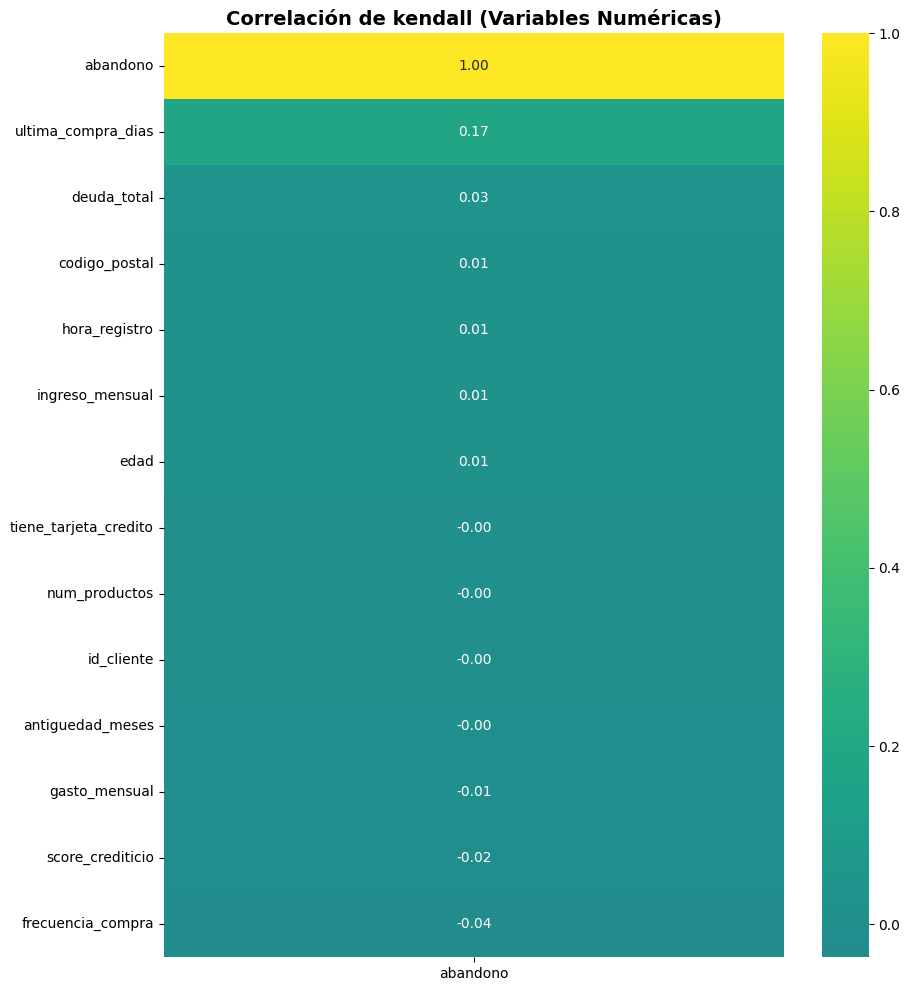

In [32]:
def analizar_correlacion_robusta(df_sucio, x_metodo = 'kendall'):
    """
    ANÁLISIS DE CORRELACIÓN DE SPEARMAN ()

    Este bloque identifica las relaciones en el dataset 'df' ignorando
    automáticamente las columnas de texto que causarían errores de conversión.

   Usamos la correlacion de Spearman porque es ideal para
       detectar tendencias en datos que aún tienen valores negativos o
       extremadamente altos (outliers).

    """
    # 1. Calculamos la matriz de correlación de Spearman
    # Agregamos numeric_only=True para evitar el error con las fechas y textos
    matriz_spearman = df_sucio.corr(
        method=x_metodo,
        numeric_only=True
    )[['abandono']].sort_values(by='abandono', ascending=False)

    # 2. Configuración visual
    plt.figure(figsize=(10, 12))

    # 3. Generamos el Heatmap
    sns.heatmap(matriz_spearman, annot=True, cmap='viridis', fmt=".2f", center=0)

    plt.title(f"Correlación de {x_metodo} (Variables Numéricas)", fontsize=14, fontweight='bold')
    plt.show()

# Ejecutamos sobre el dataset original
analizar_correlacion_robusta(df, x_metodo = 'kendall')

* Los resultados de 0.01 o -0.01 indican que, en el estado actual de los datos, las variables se comportan de forma casi aleatoria respecto a nuestro target

* Los datos crudos, por sí solos, no tienen capacidad predictiva. Esto justifica obligatoriamente el uso de imputación y Winsorizing para "rescatar" la señal del negocio

* Este gráfico es nuestra "Línea de Base". Demuestra que sin el procesamiento que nosotros diseñamos en la máquina (Pipeline), la empresa no podría tomar ninguna decisión estratégica válida

In [33]:
def analisis_bivariado_region(df):
    """
    Agrupa los datos por 'region' y 'tipo_plan' para calcular el promedio de
    'abandono' y 'gasto_mensual'.

    UTILIDAD PARA EL NEGOCIO:
    Permite una segmentación estratégica. En lugar de analizar el comportamiento
    global, este cruce identifica "focos de riesgo" al evaluar qué combinaciones
    geográficas y de producto son más propensas a cancelar el servicio.

    INTERPRETACIÓN DE LOS RESULTADOS:
    - abandono (mean): Al ser una variable binaria (0 y 1), su media representa
      exactamente la Tasa de Abandono (Churn Rate) del segmento. Un valor de 0.35
      indica que el 35% de los clientes en ese grupo canceló el servicio.

    - gasto_mensual (mean): Indica el valor promedio monetario de ese segmento.
      Cruzar una alta tasa de abandono con un alto gasto mensual permite al
      negocio priorizar qué clientes retener primero para evitar fugas de capital.

    Parámetros:
    df (pd.DataFrame): El conjunto de datos original (antes de estandarizar).

    Retorna:
    pd.DataFrame: Tabla resumen con las medias ordenadas por tasa de abandono.
    """
    # Agrupación múltiple y cálculo de la media
    resumen_grupos = df.groupby(['region', 'tipo_plan'])[['abandono', 'gasto_mensual']].mean().reset_index()

    # Ordenamos por la tasa de abandono de mayor a menor riesgo (Churn Rate)
    resumen_grupos = resumen_grupos.sort_values(by=['region', 'abandono'], ascending=False)

    print("Análisis Bivariado: Tasa de Abandono (Churn Rate) y Gasto Medio por Región y Plan")

    return resumen_grupos

# Ejecutamos la función sobre el dataframe original (antes del pipeline)
analisis_bivariado_region(df)



Análisis Bivariado: Tasa de Abandono (Churn Rate) y Gasto Medio por Región y Plan


,region,tipo_plan,abandono,gasto_mensual
6,Sur,Basico,0.460362,398899.838056
7,Sur,Estandar,0.380197,398873.557744
8,Sur,Premium,0.375108,394989.676458
3,Norte,Basico,0.450466,393699.688480
4,Norte,Estandar,0.360765,401832.410325
5,Norte,Premium,0.349262,410670.933185
0,Centro,Basico,0.475577,394980.003036
2,Centro,Premium,0.363271,400618.262469
1,Centro,Estandar,0.361776,400321.832263


Análisis Bivariado: Tasa de Abandono (Churn Rate) y Gasto Medio por Región y Plan


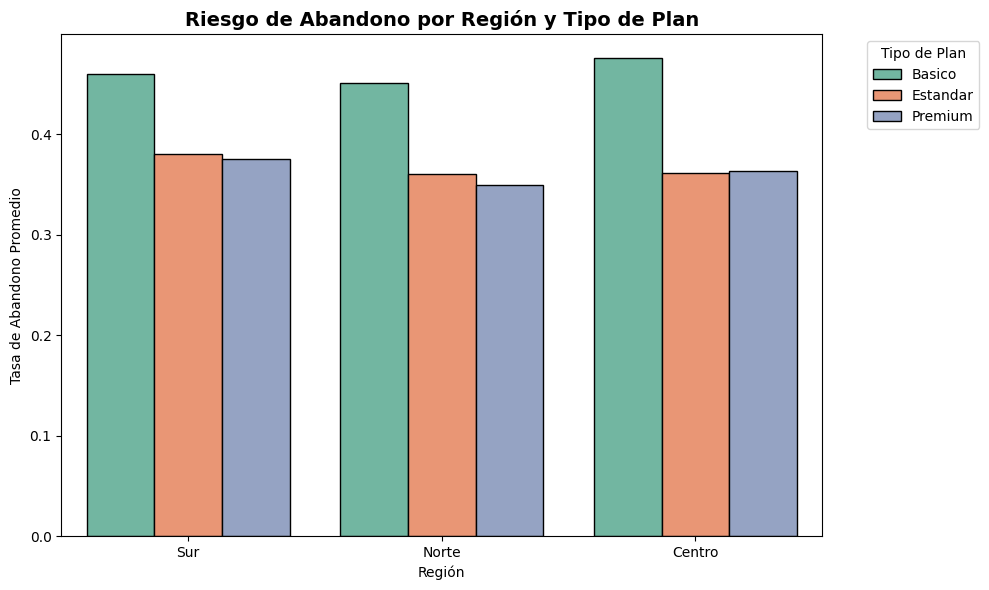

In [34]:
# Guardamos el resultado en una variable
resumen_region_plan = analisis_bivariado_region(df)

# Generamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_region_plan, x='region', y='abandono', hue='tipo_plan', palette='Set2', edgecolor='black')

plt.title('Riesgo de Abandono por Región y Tipo de Plan', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Región')
plt.legend(title='Tipo de Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta los márgenes automáticamente
plt.show()

In [35]:
def analisis_genero_abandono(df):
    """
    Realiza un análisis exploratorio agrupando los datos por género.

    Agrupa los datos por la columna 'genero' para calcular el promedio de
    'abandono' y 'gasto_mensual' de cada segmento demográfico.

    UTILIDAD PARA EL NEGOCIO:
    Permite identificar si el género de los clientes es un factor determinante
    en su decisión de cancelar el servicio. Si un género específico presenta
    una tasa de abandono significativamente más alta, el área de marketing o
    producto puede investigar si el contenido, el servicio o las campañas de
    retención actuales están desalineados con las necesidades de ese grupo.

    INTERPRETACIÓN DE LOS RESULTADOS:
    - abandono (mean): Muestra el porcentaje exacto de clientes de cada género
      que cancelaron su suscripción (Churn Rate). Un valor de 0.40 significa que
      el 40% de ese segmento abandonó la empresa.
    - gasto_mensual (mean): Contextualiza el impacto financiero. Si el género
      con mayor tasa de fuga es también el que tiene un gasto mensual más alto,
      la empresa enfrenta una pérdida de ingresos crítica.

    Parámetros:
    df (pd.DataFrame): El conjunto de datos original (antes de estandarizar).

    Retorna:
    pd.DataFrame: Tabla resumen con las medias ordenadas por tasa de abandono.
    """
    # Agrupación por género y cálculo de la media
    resumen_genero = df.groupby('genero')[['abandono', 'gasto_mensual']].mean().reset_index()

    # Ordenamos por la tasa de abandono de mayor a menor riesgo (Churn Rate)
    resumen_genero = resumen_genero.sort_values(by='abandono', ascending=False)

    print("Análisis Bivariado: Tasa de Abandono y Gasto Medio por Género")

    return resumen_genero

# Ejecutamos la función sobre el dataframe original
analisis_genero_abandono(df)

Análisis Bivariado: Tasa de Abandono y Gasto Medio por Género


,genero,abandono,gasto_mensual
2,Otro,0.400743,399379.044207
1,Masculino,0.395492,398375.098759
0,Femenino,0.394043,400589.978117


Análisis Bivariado: Tasa de Abandono y Gasto Medio por Género


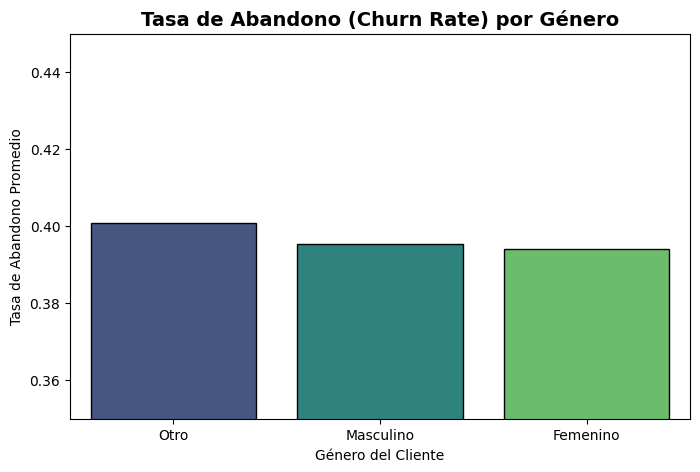

In [37]:
# Guardamos el resultado en una variable para graficarlo
resumen_genero = analisis_genero_abandono(df)

# Generamos el gráfico
plt.figure(figsize=(8, 5))

sns.barplot(data=resumen_genero, x='genero', y='abandono', hue='genero', palette='viridis', edgecolor='black', legend=False)

plt.title('Tasa de Abandono (Churn Rate) por Género', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Género del Cliente')

plt.ylim(0.35, 0.45)
plt.show()

In [39]:
def analisis_antiguedad_genero(df):
    """
    Realiza un análisis exploratorio avanzado cruzando variables demográficas
    y de ciclo de vida del cliente mediante discretización (Binning).

    Primero, transforma la variable continua 'antiguedad_meses' en rangos
    categóricos (0-2 años, 2-5 años, 5+ años). Luego, realiza una agrupación
    múltiple por 'genero' y este nuevo 'rango_antiguedad' para evaluar el
    'abandono' y el 'gasto_mensual'.

    UTILIDAD PARA EL NEGOCIO:
    Permite descubrir en qué momento exacto del "ciclo de vida" el cliente es
    más vulnerable a la fuga, segmentado por género. Por ejemplo, podría revelar
    que los hombres abandonan mucho en sus primeros 2 años, mientras que las
    mujeres lo hacen después de los 5 años. Esto ayuda a diseñar campañas de
    fidelización con un "timing" (momento) perfecto y mensajes personalizados.

    INTERPRETACIÓN DE LOS RESULTADOS:
    - abandono (mean):  Un 0.50 significa que la mitad
      de los clientes de ese género y antigüedad específica ya cancelaron.
    - gasto_mensual (mean): Ayuda a medir la pérdida económica de esa fuga.

    Parámetros:
    df (pd.DataFrame): El conjunto de datos original.

    Retorna:
    pd.DataFrame: Tabla resumen con las medias cruzadas.
    """
    # 1. Creamos una copia temporal para no alterar el dataset original crudo
    temp_df = df.copy()

    # 2. Discretización (Binning): Convertimos los meses en categorías lógicas
    # Definimos los cortes: 0 a 24 meses (2 años), 24 a 60 (5 años), 60 a 120 (10 años)
    cortes = [0, 24, 60, 120]
    etiquetas = ['Nuevos (0-2 años)', 'Regulares (2-5 años)', 'Veteranos (5+ años)']

    # Aplicamos pd.cut para crear la nueva columna categórica
    temp_df['rango_antiguedad'] = pd.cut(temp_df['antiguedad_meses'], bins=cortes, labels=etiquetas)

    # 3. Agrupación múltiple compleja
    resumen_antiguedad = temp_df.groupby(['genero', 'rango_antiguedad'], observed=False)[['abandono', 'gasto_mensual']].mean().reset_index()

    # 4. Ordenamos por género, y luego por mayor tasa de abandono
    resumen_antiguedad = resumen_antiguedad.sort_values(by=['genero', 'abandono'], ascending=[True, False])

    print("=== Análisis Bivariado: Tasa de Abandono por Género y Etapa del Ciclo de Vida (Antigüedad) ===")

    return resumen_antiguedad

# Ejecutamos la función sobre el dataframe original
analisis_antiguedad_genero(df)

=== Análisis Bivariado: Tasa de Abandono por Género y Etapa del Ciclo de Vida (Antigüedad) ===


,genero,rango_antiguedad,abandono,gasto_mensual
1,Femenino,Regulares (2-5 años),0.399902,402737.809388
2,Femenino,Veteranos (5+ años),0.391940,401878.763241
0,Femenino,Nuevos (0-2 años),0.390406,394211.900645
5,Masculino,Veteranos (5+ años),0.397024,397556.953214
4,Masculino,Regulares (2-5 años),0.396745,399067.174353
3,Masculino,Nuevos (0-2 años),0.389767,399418.490232
6,Otro,Nuevos (0-2 años),0.407989,406393.760449
7,Otro,Regulares (2-5 años),0.402101,395917.334094
8,Otro,Veteranos (5+ años),0.397029,398638.769724


=== Análisis Bivariado: Tasa de Abandono por Género y Etapa del Ciclo de Vida (Antigüedad) ===


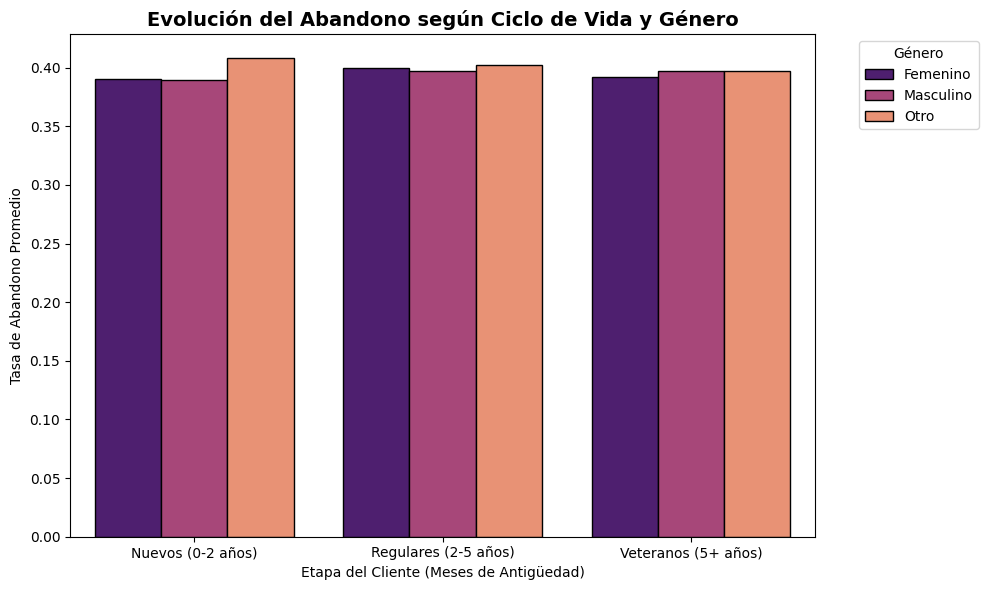

In [40]:
# Guardamos el resultado
resumen_antiguedad = analisis_antiguedad_genero(df)

# Generamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_antiguedad, x='rango_antiguedad', y='abandono', hue='genero', palette='magma', edgecolor='black')

plt.title('Evolución del Abandono según Ciclo de Vida y Género', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Etapa del Cliente (Meses de Antigüedad)')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
def perfilamiento_avanzado_gerencial(df):
    """
    Realiza un perfilamiento avanzado de clientes en riesgo mediante filtrado
    complejo y enriquece los datos integrando información de gerencia zonal.

    TÉCNICAS UTILIZADAS:
    1. Filtros Avanzados: Uso de máscaras booleanas múltiples con operadores lógicos (&).
    2. Joins Complejos: Creación de un DataFrame maestro secundario y cruce
       mediante pd.merge() tipo 'left join'.
    3. Manejo de Excepciones: Bloque try-except para capturar errores de llaves
       (KeyError) en caso de que las columnas ya hayan sido transformadas.

    UTILIDAD ANALÍTICA (VALOR DE NEGOCIO):
    El filtro identifica un perfil paradójico y muy valioso: Clientes que están
    fuertemente endeudados, pero que usan la App con nivel 'Alto'. Estos usuarios
    son altamente digitales y comprometidos con el servicio, pero cancelan por
    estrés financiero. Al cruzar (Join) esta base filtrada con los Gerentes Zonales,
    creamos un "Reporte de Acción Inmediata" donde cada gerente sabe exactamente
    a qué clientes llamar para ofrecerles un salvavidas (ej. un descuento o
    congelamiento temporal de tarifa) antes de que se vayan a la competencia.

    Parámetros:
    df (pd.DataFrame): El conjunto de datos original.

    Retorna:
    pd.DataFrame: DataFrame enriquecido solo con los clientes críticos asignados.
    """
    print("=== Iniciando Perfilamiento Gerencial Avanzado ===")

    try:
        # 1. FILTRO AVANZADO: Buscamos el perfil de "Alto Riesgo Financiero pero Alta Fidelidad Digital"
        # Máscara con 3 condiciones (Uso de &)
        mascara_riesgo = (
            (df['abandono'] == 1) &
            (df['deuda_total'] > df['ingreso_mensual']) &
            (df['uso_app'] == 'Alto')
        )

        filtro_alto_riesgo = df[mascara_riesgo].copy()

        if filtro_alto_riesgo.empty:
            print("No se encontraron clientes con este perfil específico en el dataset.")
            return None

        print(f"Filtro aplicado: Se encontraron {len(filtro_alto_riesgo)} clientes en riesgo financiero crítico.")

        # 2. TABLA SECUNDARIA: Simulamos una tabla maestra de gerencia operativa
        datos_gerentes = pd.DataFrame({
            'region': ['Norte', 'Centro', 'Sur', 'Otro'],
            'gerente_zonal': ['Gerente Norte', 'Gerente Centro', 'Gerente Sur', 'Sin Asignar'],
            'presupuesto_retencion': [500000, 750000, 600000, 0]
        })

        # 3. JOIN COMPLEJO: Cruzamos la base filtrada con la tabla de gerentes
        # Usamos un Left Join para mantener a todos los clientes críticos y solo traer el "nombre" del gerente referencial de la zona
        reporte_final = pd.merge(filtro_alto_riesgo, datos_gerentes, on='region', how='left')

        print(" Join realizado exitosamente con la tabla maestra de Gerentes Zonales.")
        print("\n--- Vista Previa del Reporte de Acción para Gerencia ---")

        # Mostramos columnas clave para la toma de decisiones
        columnas_vista = ['id_cliente', 'region', 'gerente_zonal', 'ingreso_mensual', 'deuda_total', 'tipo_plan']
        display(reporte_final[columnas_vista].head())

        return reporte_final

    # 4. MANEJO DE EXCEPCIONES
    except KeyError as e:
        print(f"ERROR (KeyError): No se encontró la columna {e}. ")
        return None
    except Exception as e:
        print(f"ERROR INESPERADO: Ocurrió un problema durante el procesamiento: {e}")
        return None

# Ejecutamos la función sobre el dataframe con datos crudos
reporte_gerencial = perfilamiento_avanzado_gerencial(df)

=== Iniciando Perfilamiento Gerencial Avanzado ===
Filtro aplicado: Se encontraron 1983 clientes en riesgo financiero crítico.
 Join realizado exitosamente con la tabla maestra de Gerentes Zonales.

--- Vista Previa del Reporte de Acción para Gerencia ---


,id_cliente,region,gerente_zonal,ingreso_mensual,deuda_total,tipo_plan
0,4,Sur,Gerente Sur,4.369032e+05,2.999350e+06,Estandar
1,8,Sur,Gerente Sur,5.118506e+05,1.457150e+06,Basico
2,12,Centro,Gerente Centro,7.252641e+05,1.826565e+06,Basico
3,13,Centro,Gerente Centro,1.058150e+06,1.819410e+06,Estandar
4,33,Norte,Gerente Norte,2.605659e+05,1.844618e+06,Basico


6) Ingenieria de caracteristicas

In [42]:
def agregar_variables(data: pd.DataFrame):
    """
    Agrega nuevas variables al set de datos original mediante ingeniería de características.

    Creamos la variable 'ratio_deuda' (deuda_total / ingreso_mensual) y
    una clasificación ordinal 'riesgo_financiero' ('Alto' o 'Bajo' según si la deuda supera el 50% del ingreso).

    Justificación de negocio: Estas variables aportan gran valor predictivo para el modelo.
    Un cliente con una alta carga financiera (ratio > 0.5) está asfixiado económicamente y
    es sumamente propenso a cancelar suscripciones de servicios digitales para ahorrar,
    impactando directamente en la tasa de abandono que la empresa busca reducir.

    Parámetros:
        data (pd.DataFrame): El conjunto de datos base que contiene la información de los clientes.

    Retorna:
        pd.DataFrame: Un nuevo DataFrame con las columnas calculadas añadidas.
    """
    # Trabajaremos sobre una copia para no alterar el DataFrame original accidentalmente
    data = data.copy()

    # Primero calculamos la proporción de la deuda frente al ingreso (Variable Numérica)
    data['ratio_deuda'] = data['deuda_total'] / data['ingreso_mensual']

    # Luego clasificamos el riesgo financiero usando numpy (Variable Categórica Ordinal)
    # Si ratio_deuda es mayor a 0.5, asigna 'Alto', de lo contrario asigna 'Bajo'
    data['riesgo_financiero'] = np.where(data['ratio_deuda'] > 0.5, 'Alto', 'Bajo')

    return data

df = agregar_variables(df)
df

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono,ratio_deuda,riesgo_financiero
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,Estandar,3,1,Tienda,Lunes,22,3824,1,2.648631,Alto
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,Premium,4,1,App,Martes,10,4148,0,1.170350,Alto
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,Premium,4,1,App,Jueves,6,7200,0,NaN,Bajo
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,Estandar,2,1,App,Domingo,16,1782,1,6.865021,Alto
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,Estandar,3,1,Web,Martes,8,3448,1,2.210565,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,Basico,1,0,Web,Viernes,4,5831,0,3.633635,Alto
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,Premium,3,0,Web,Domingo,17,2925,0,1.756537,Alto
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,Estandar,4,0,App,Viernes,16,1660,0,1.167075,Alto
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,Premium,2,0,Tienda,Lunes,14,4561,1,2.522305,Alto


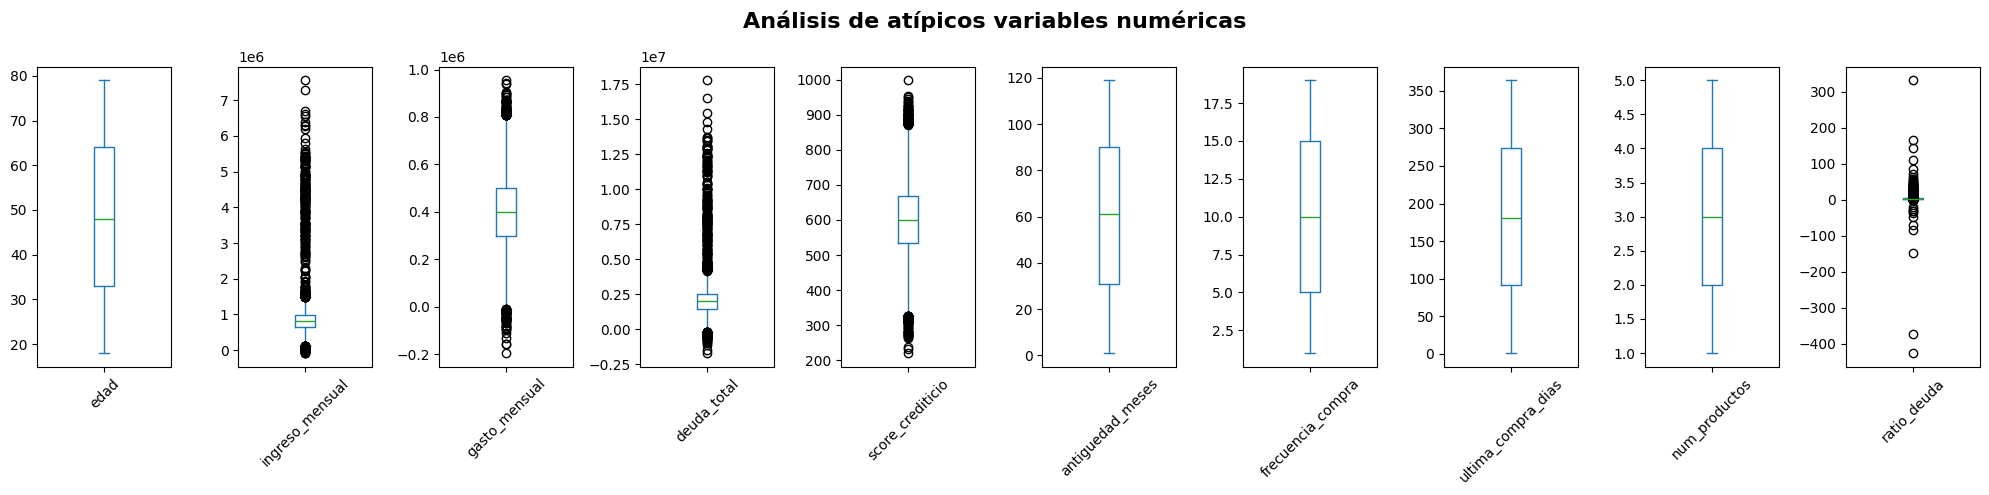

In [43]:
def visualizar_atipicos_numericos(df, revision):
    """

    Esta función filtra las variables numéricas relevantes según la metadata del negocio
    (excluyendo identificadores, variables espaciales, de tiempo o binarias) y genera un
    lienzo con subgráficos de caja. Esto permite diagnosticar la calidad de los datos
    antes de aplicar métodos de corrección de outliers (como Winsorizer).

    Parámetros:
        df (pd.DataFrame): El conjunto de datos base que contiene la información de los clientes.

    Retorna:
        None: Renderiza la visualización de matplotlib directamente.
    """

    # Lista de columnas numéricas seleccionadas para el análisis (PASAR ESO A UN PARÁMETRO DE LA FUNCIÓN)


    fig, axes = plt.subplots(1, len(revision), figsize=(20, 5))
    axes = axes.flatten() # Convierte la matriz de ejes en un vector

    # Iteramos sobre las columnas para generar cada boxplot
    for i, col in enumerate(revision):
        df[col].plot(kind='box', ax=axes[i])
        axes[i].tick_params(axis="x", labelrotation=45)

    # Configuramos los títulos y ajustamos el diseño
    plt.suptitle("Análisis de atípicos variables numéricas", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Visualizamos el grafico:
visualizar_atipicos_numericos(df, numeric_features)

7) Configuracion y aplicacion de Winsorizer y nuestro Pipeline

In [44]:
# para lidiar con los valores atipicos usamos WINSORIZER, este codigo nos permite acortar el "piso y techo" de nuestros datos, en este caso, ajustando los datos en un 5% (al interior) respectivamente
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [45]:
# funcion para eliminar duplicados, señalando el data frame, lo invocaremos en nuestro pipeline
def eliminar_duplicados(X):
  return X.drop_duplicates()

In [47]:
"""
DEFINICIÓN DE VARIABLES POR NATURALEZA TÉCNICA

En este bloque categorizamos las variables del dataset para su tratamiento en el Pipeline.
Es fundamental distinguir entre los 'predictores' y la 'variable objetivo'.

JUSTIFICACIÓN DE 'TIENE_TARJETA_CREDITO' VS 'ABANDONO':
Aunque ambas variables son nominales y binarias (0/1), se gestionan de forma distinta:
1. 'tiene_tarjeta_credito': Es un PREDICTOR que el modelo utiliza para aprender patrones
   de comportamiento. Por ello, se incluye en el procesamiento para ser normalizado.

2. 'abandono': Es la VARIABLE OBJETIVO (Target) que deseamos predecir.
  No se incluye en las listas de preprocesamiento para evitar el 'Data Leakage' (fuga de datos),
   asegurando que el modelo aprenda a predecir el Churn basándose en el comportamiento
   previo del cliente y no en la respuesta misma.
"""

# Definimos las variables categóricas nominales (sin orden jerárquico)
categorical_nominal_features = [
    'genero',
    'region',
    'estado_civil',
    'canal_registro',
    'dia_semana_registro',
    'tiene_tarjeta_credito'  # Funciona como nominal (Sí/No) para el aprendizaje
]

In [48]:
categorical_ordinal_features = [
    'uso_app',          # Alto, Medio, Bajo
    'tipo_plan',        # Básico, Estándar, Premium
    'riesgo_financiero' # Alto, Bajo (Nuestra otra variable nueva)
]

Necesitamos conocer los valores unicos de las siguientes columnas para evitar problemas durante su tratamiento en el pipeline

In [49]:
df['uso_app'].unique()

array(['Bajo', 'Medio', 'Alto'], dtype=object)

In [50]:
df['tipo_plan'].unique()

array(['Estandar', 'Premium', 'Basico'], dtype=object)

In [51]:
df['riesgo_financiero'].unique()

array(['Alto', 'Bajo'], dtype=object)

In [52]:
def crear_pipeline_procesamiento():
    """
    Construye el motor de preprocesamiento automatizado (Pipeline) para el conjunto de datos.

    La estandarización, imputación y codificación se realizan INTERNAMENTE para garantizar
    la reproducibilidad y evitar el sesgo de datos (data leakage).

    JUSTIFICACIÓN DE LOS PROCESOS ELEGIDOS:

    1. Pipeline Numérico:
       - Winsorizer (0.05, 0.95): Se eligió este límite para mitigar el impacto de valores extremos
         en variables como 'deuda_total' e 'ingreso_mensual'. En lugar de eliminar filas,
         "aplastamos" los outliers al percentil 5 y 95 para conservar la información del negocio.

       - Imputación (mean): Se utiliza la media para rellenar nulos en 'gasto_mensual' e 'ingreso_mensual'
         asumiendo una distribución relativamente normal tras el winsorizing, manteniendo el centro de la masa de datos.

       - MinMaxScaler: Se seleccionó para normalizar todas las magnitudes al rango [0, 1].
         Esto es vital para que variables con escalas grandes (deuda) no opaquen a las pequeñas (edad) en el modelo.

    2. Pipeline Nominal (OneHotEncoder):
       - Se aplica a variables sin jerarquía (genero, region). Se eligió OneHot para crear columnas binarias
         independientes, permitiendo que el modelo entienda la presencia de una categoría sin asumir que
         una región es "mayor" que otra.

    3. Pipeline Ordinal (OrdinalEncoder):
       - Se utiliza para 'uso_app', 'tipo_plan' y 'riesgo_financiero' . A diferencia de OneHot,
         aquí elegimos mantener un orden numérico (0 < 1 < 2) porque existe una jerarquía lógica clara
         (Básico < Estándar < Premium) que aporta valor predictivo.

    4. Limpieza de Filas (FunctionTransformer):
       - Se integra la eliminación de duplicados para centralizar toda la lógica de limpieza
         en un solo objeto de flujo de trabajo.

    Retorna:
        Pipeline: Flujo de trabajo de Scikit-Learn listo para .fit_transform().
    """

    # 1. Pipeline para variables numéricas (Limpieza + Imputación + Escalado)
    pipeline_numerico = Pipeline(
        steps=[
            ("winsorizer", Winsorizer(limits=(0.05, 0.05))),
            ("imputacion", SimpleImputer(strategy="mean")),
            ("escalado", MinMaxScaler())
        ]
    )

    # 2. Pipeline para variables categóricas Nominales (Sin orden -> OneHot)
    pipeline_nominal = Pipeline(
        steps=[
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
        ]
    )

    # 3. Pipeline para variables categóricas Ordinales (Con orden -> OrdinalEncoder)
    pipeline_ordinal = Pipeline(
        steps=[
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(categories=[
                ['Bajo', 'Medio', 'Alto'],          # Orden para 'uso_app'
                ['Basico', 'Estandar', 'Premium'],  # Orden para 'tipo_plan'
                ['Bajo', 'Alto']                    # Orden para 'riesgo_financiero'
            ]))
        ]
    )

    # 4. Ensamblador principal: Une los 3 mini-pipelines
    preprocesador = ColumnTransformer(
        transformers=[
            ("num", pipeline_numerico, numeric_features),
            ("cat_nom", pipeline_nominal, categorical_nominal_features),
            ("cat_ord", pipeline_ordinal, categorical_ordinal_features)
        ]
    )

    # 5. Pipeline Final
    pipeline_final = Pipeline(
        steps=[
            ("duplicados", FunctionTransformer(eliminar_duplicados)),
            ("preprocesamiento", preprocesador)
        ]
    )

    return pipeline_final

mi_pipeline = crear_pipeline_procesamiento()
# 2. Pasamos nuestro DataFrame por la máquina para obtener los datos listos
data_clean_array = mi_pipeline.fit_transform(df)

creamos el data frame nuevo

In [53]:
"""
RECONSTRUCCIÓN, LIMPIEZA FINAL Y EXPORTACIÓN DEL DATASET

Este bloque realiza la transición final desde la matriz numérica generada por el pipeline
hacia un DataFrame de Pandas estructurado y listo para el análisis o modelamiento.

Procesos incluidos:
1. Reconstrucción: Convierte la salida del pipeline en un DataFrame, recuperando los nombres
   de las columnas mediante el método 'get_feature_names_out' del preprocesador.

2. Limpieza de nombres de columna: Elimina los prefijos técnicos (num__, cat_nom__, cat_ord__)
   para que los nombres coincidan con el diccionario de datos original.

3. Consistencia de Tipos: Realiza el casting (cambiar el tipo de dato de una variable de una forma a otra)
de las variables de la lista 'numeric_features'
a formato numérico para asegurar que Pandas interprete correctamente las magnitudes.

4. Recuperación de Variable Objetivo: Se reincorpora la columna 'abandono' al set de datos limpio.
   Este paso es fundamental para el entrenamiento posterior; se realiza aplicando la misma
   lógica de eliminación de duplicados para asegurar que las 20,000 etiquetas calcen
   perfectamente con las 20,000 filas procesadas por el pipeline .

5. Persistencia: Exporta el dataset final a un archivo CSV ('dataset_clientes_limpio.csv')o.
"""

# 3. Reconstruimos el DataFrame limpio
data_clean = pd.DataFrame(
    data_clean_array,
    columns=mi_pipeline.named_steps["preprocesamiento"].get_feature_names_out()
)

# 4. Limpieza de nombres de columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat_nom__", "")
data_clean.columns = data_clean.columns.str.replace("cat_ord__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

# --- Recuperación del Abandono ---
# Como el pipeline redujo el dataset a 20.000 filas, debemos extraer
# las 20.000 etiquetas de abandono correspondientes.
data_clean['abandono'] = df.drop_duplicates()['abandono'].values

# 5.EXPORTACIÓN: Guardamos el archivo final para GitHub
data_clean.to_csv('dataset_clientes_limpio.csv', index=False)

# Mostramos el resultado final
data_clean.head()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,ratio_deuda,...,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,uso_app,tipo_plan,riesgo_financiero,abandono
0,0.818182,0.638167,0.750001,0.648654,0.069273,0.886792,0.277778,1.000000,0.50,0.350003,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
1,0.545455,1.000000,0.328167,0.344409,0.426879,0.547170,0.388889,0.878049,0.75,0.082658,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,0
2,0.490909,0.496368,0.474789,1.000000,1.000000,0.000000,0.611111,0.649390,0.75,0.371217,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,0.0,0
3,0.600000,0.059194,0.535374,0.851296,0.031360,0.000000,0.111111,0.445122,0.25,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1
4,0.181818,0.420252,0.683403,0.350711,0.107477,0.066038,0.222222,0.804878,0.50,0.270779,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1


# Ahora repetimos todo el analisis que realizamos en principio para nuestro set de datos ya tratado

In [54]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   edad                           20000 non-null  float64
 1   ingreso_mensual                20000 non-null  float64
 2   gasto_mensual                  20000 non-null  float64
 3   deuda_total                    20000 non-null  float64
 4   score_crediticio               20000 non-null  float64
 5   antiguedad_meses               20000 non-null  float64
 6   frecuencia_compra              20000 non-null  float64
 7   ultima_compra_dias             20000 non-null  float64
 8   num_productos                  20000 non-null  float64
 9   ratio_deuda                    20000 non-null  float64
 10  genero_Femenino                20000 non-null  float64
 11  genero_Masculino               20000 non-null  float64
 12  genero_Otro                    20000 non-null 

In [55]:
data_clean.isna().sum()

,0
edad,0
ingreso_mensual,0
gasto_mensual,0
deuda_total,0
score_crediticio,0
antiguedad_meses,0
frecuencia_compra,0
ultima_compra_dias,0
num_productos,0
ratio_deuda,0


In [56]:
data_clean.duplicated().sum()

np.int64(0)

In [57]:
data_clean.describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,ratio_deuda,...,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,uso_app,tipo_plan,riesgo_financiero,abandono
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.500272,0.496368,0.499379,0.490913,0.502989,0.501879,0.497597,0.498230,0.499025,0.371217,...,0.143350,0.146700,0.140150,0.141350,0.499200,0.500800,0.995350,1.011050,0.921150,0.396750
std,0.319244,0.267560,0.269897,0.275429,0.268297,0.317326,0.303375,0.315754,0.352596,0.254329,...,0.350438,0.353815,0.347151,0.348391,0.500012,0.500012,0.818695,0.814408,0.269511,0.489236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.218182,0.306298,0.305226,0.286371,0.314042,0.226415,0.222222,0.222561,0.250000,0.188698,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.490909,0.496368,0.499379,0.489961,0.502989,0.509434,0.500000,0.493902,0.500000,0.339265,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,0.781818,0.684991,0.690068,0.688693,0.692701,0.783019,0.777778,0.777439,0.750000,0.493689,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000


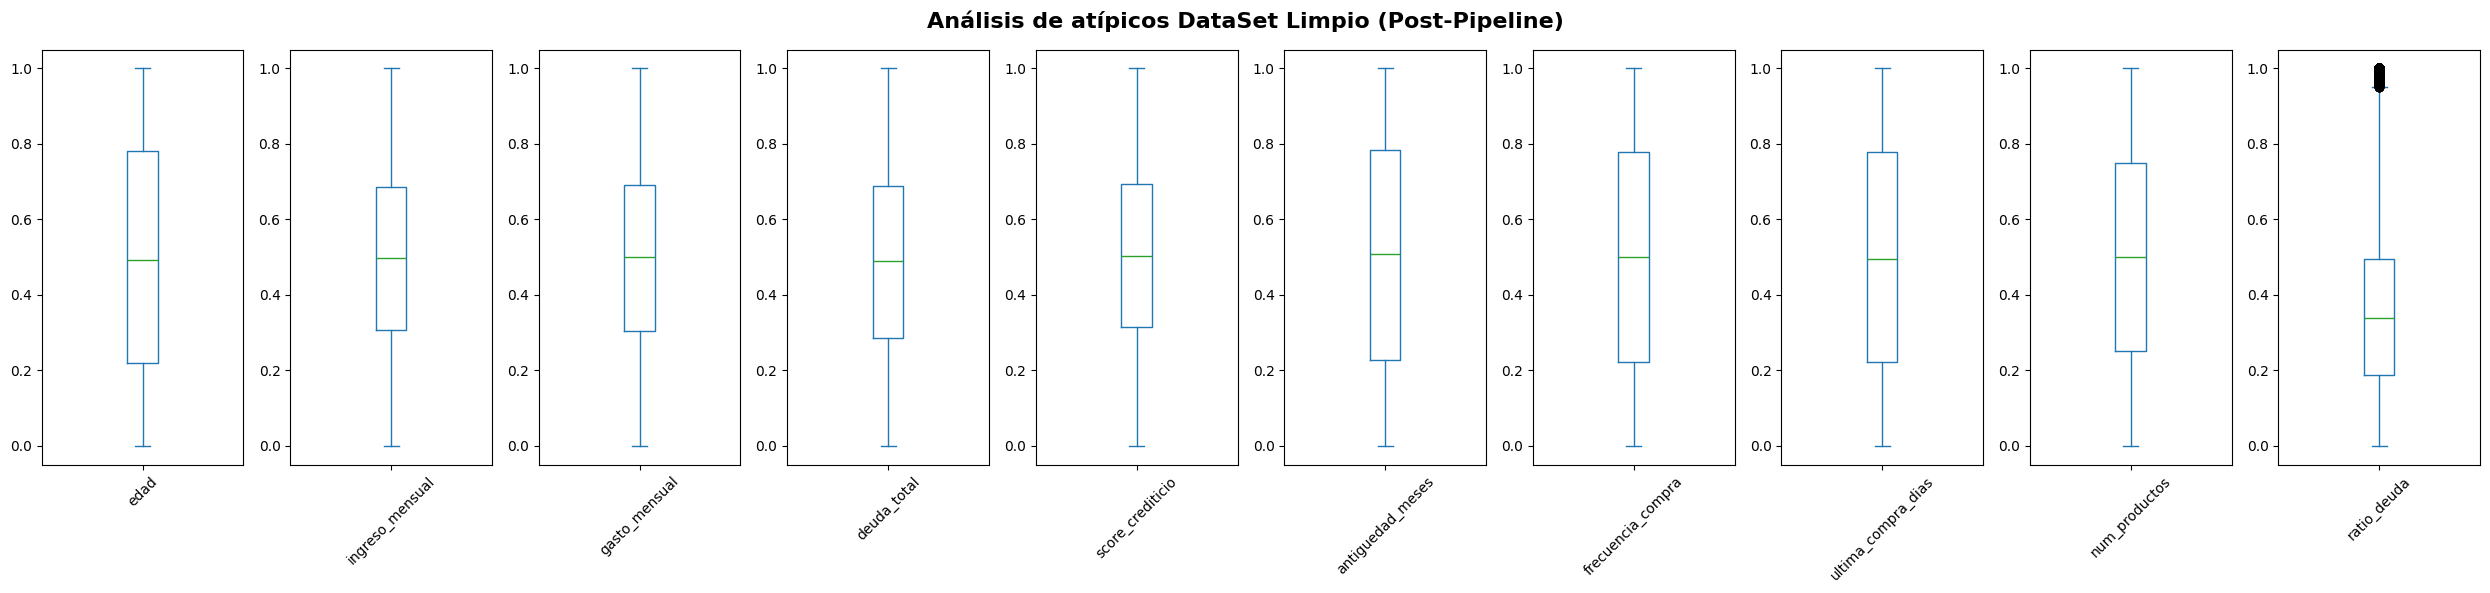

In [58]:
# Tomamos las columnas numericas que definimos para el Pipeline
revision_atipicos_dataClean = data_clean[numeric_features]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(25, 6))
axes = axes.flatten() # convierte la matriz de ejes en un vector

# 3. Iteramos sobre las columnas del nuevo dataframe limpio
for i, col in enumerate(numeric_features):
    data_clean[col].plot(kind='box', ax=axes[i])
    axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos DataSet Limpio (Post-Pipeline)", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

Como pueden observar en los gráficos de validación finales, todas nuestras variables numéricas quedaron perfectamente estandarizadas entre 0 y 1. Sin embargo, hay un detalle interesante en la variable que creamos, el ratio_deuda: a pesar de haber pasado por el pipeline, sigue mostrando valores atípicos en el boxplot.


Al analizar este comportamiento, identificamos que ocurre por dos motivos, y decidimos mantenerlo así de forma estratégica:

La justificación técnica: Esto es producto de un choque matemático. Nuestro Winsorizer actuó correctamente poniendo un techo estadístico al 5% de los datos más extremos. Pero, como esta variable es la división entre la deuda y los ingresos de los clientes, tiene una distribución tan asimétrica que ese 'techo' sigue siendo lo suficientemente alto como para que el gráfico de Boxplot lo dibuje como un atípico. La variable está contenida y no romperá el modelo, pero sigue mostrando sus extremos.

La justificación de negocio (El valor real): Lejos de ser un error, decidimos conservar esta distribución porque realmente aporta al análisis. Esos puntos atípicos representan exactamente a los clientes que el negocio necesita detectar: personas que están asfixiadas económicamente. Al mantener este comportamiento, le estamos entregando al futuro modelo de Machine Learning una señal clarísima para predecir qué clientes son los más propensos a cancelar el servicio por problemas de dinero.

# factores que aumentan la ida de un cliente

In [59]:
"""
Los algoritmos de Machine Learning requieren que todas las variables sean numéricas.
Por ello, nuestro Pipeline transformó las categorías de texto en múltiples columnas
binarias (One-Hot Encoding) y escalas numéricas (Ordinal Encoding). Sin embargo,
para el Análisis Bivariado y la generación de gráficos (EDA Post-Pipeline), los
humanos necesitamos leer las etiquetas originales ('Norte', 'Basico', 'Femenino').

Este bloque realiza una "ingeniería inversa temporal" exclusiva para graficar,
garantizando que visualicemos los datos ya limpios (sin nulos y con outliers
tratados) pero con etiquetas legibles.

MECÁNICA TÉCNICA (Cómo funciona):
1. .copy():
   Crea 'df_plot'. Es crucial para aislar esta transformación; asegura que
   'data_clean' siga siendo una matriz puramente matemática lista para el modelo.

2. .idxmax(axis=1) y .str.replace() [Para One-Hot Encoding]:
   Las variables 'region' y 'genero' están divididas en varias columnas de 0s y 1s.

   - `idxmax(axis=1)` busca fila por fila (horizontalmente) y devuelve el NOMBRE de
     la columna que contiene el valor máximo (es decir, el 1).

   - `.str.replace()` limpia ese nombre (ej. transforma 'region_Norte' a 'Norte'),
     reconstruyendo la columna original en un solo paso vectorizado.

3. .map() [Para Ordinal Encoding]:
   La variable 'tipo_plan' fue transformada a 0.0, 1.0 y 2.0.
   Usando un diccionario (`mapa_plan`), la función `.map()` busca cada número y
   lo sustituye directamente por su etiqueta jerárquica de texto correspondiente.
"""

# Creamos una copia específica para graficar sin alterar data_clean
df_plot = data_clean.copy()

# A. Reconstruir 'region' desde las columnas One-Hot usando idxmax
cols_region = ['region_Centro', 'region_Norte', 'region_Sur']
df_plot['region'] = df_plot[cols_region].idxmax(axis=1).str.replace('region_', '')

# B. Reconstruir 'genero'
cols_genero = ['genero_Femenino', 'genero_Masculino', 'genero_Otro']
df_plot['genero'] = df_plot[cols_genero].idxmax(axis=1).str.replace('genero_', '')

# C. Reconstruir 'tipo_plan' a texto
mapa_plan = {0.0: 'Basico', 1.0: 'Estandar', 2.0: 'Premium'}
df_plot['tipo_plan_nom'] = df_plot['tipo_plan'].map(mapa_plan)




=== Análisis Bivariado Clean: Tasa de Abandono y Gasto Medio por Región y Plan ===


,region,tipo_plan_nom,abandono,gasto_mensual
0,Centro,Basico,0.475113,0.491986
1,Centro,Estandar,0.363920,0.499983
2,Centro,Premium,0.363057,0.501482
3,Norte,Basico,0.449137,0.490618
4,Norte,Estandar,0.359347,0.502699
5,Norte,Premium,0.348940,0.518399
6,Sur,Basico,0.460919,0.498089
7,Sur,Estandar,0.381349,0.498111
8,Sur,Premium,0.374671,0.492756


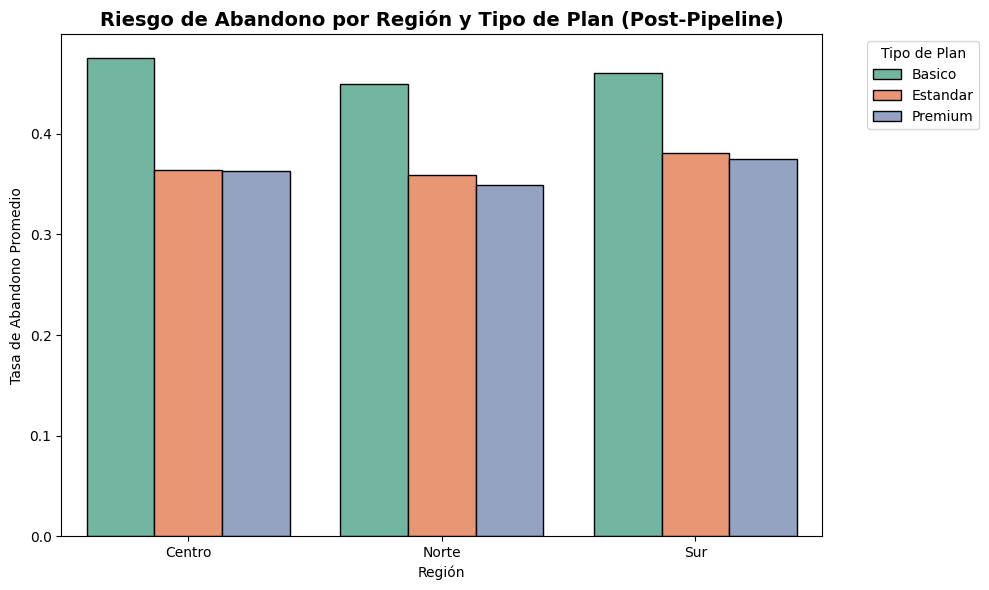

In [60]:
def analisis_bivariado_region_clean(df):
    """
    Calcula la tasa de abandono y el gasto promedio agrupado por región y tipo de plan,
    utilizando las variables categóricas reconstruidas tras el preprocesamiento.

    Esta función agrupa los datos para identificar qué combinaciones geográficas
    y de servicio presentan un mayor riesgo de fuga (Churn Rate), permitiendo
    al negocio priorizar estrategias de retención segmentadas.

    Parámetros:
    -----------
    df : pandas.DataFrame
        El conjunto de datos preparado para visualización, que debe incluir
        las columnas reconstruidas 'region' y 'tipo_plan_nom'.

    Retorna:
    --------
    pandas.DataFrame
        Tabla resumen con las medias de 'abandono' y 'gasto_mensual', ordenada
        por región y, dentro de cada región, de mayor a menor riesgo de abandono.
    """
    # Agrupamos con las variables reconstruidas
    resumen_grupos = df.groupby(['region', 'tipo_plan_nom'])[['abandono', 'gasto_mensual']].mean().reset_index()
    resumen_grupos = resumen_grupos.sort_values(by=['region', 'abandono'], ascending=[True, False])

    print("=== Análisis Bivariado Clean: Tasa de Abandono y Gasto Medio por Región y Plan ===")
    return resumen_grupos

# Guardamos el resultado
resumen_region_plan_clean = analisis_bivariado_region_clean(df_plot)
display(resumen_region_plan_clean)

# Generamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_region_plan_clean, x='region', y='abandono', hue='tipo_plan_nom', palette='Set2', edgecolor='black')
plt.title('Riesgo de Abandono por Región y Tipo de Plan (Post-Pipeline)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Región')
plt.legend(title='Tipo de Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

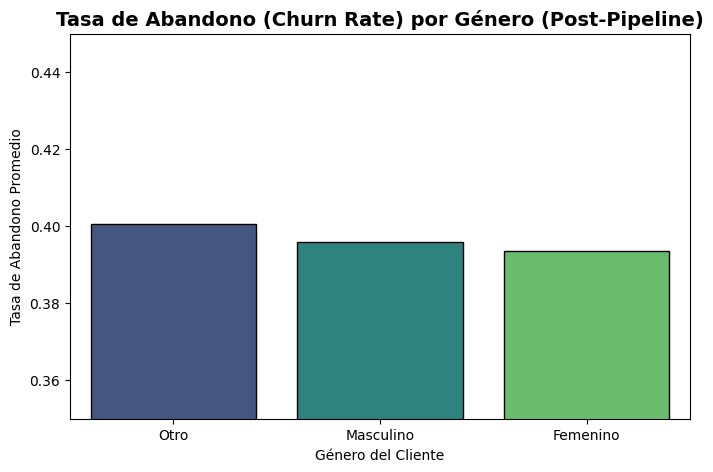

In [61]:
def analisis_genero_abandono_clean(df):
    """
    Realiza un análisis exploratorio de la tasa de abandono y el gasto mensual
    promedio segmentado exclusivamente por el género del cliente.

    Permite identificar si un género específico tiene una mayor propensión
    a cancelar el servicio, lo que ayuda a evaluar si el producto, el contenido
    o las campañas de marketing están desalineados con algún segmento demográfico.

    Parámetros:
    -----------
    df : pandas.DataFrame
        El conjunto de datos preparado para visualización con la columna 'genero'
        ya reconstruida desde su formato One-Hot.

    Retorna:
    --------
    pandas.DataFrame
        Tabla resumen con las medias de 'abandono' y 'gasto_mensual' por género,
        ordenada de mayor a menor riesgo de abandono.
    """
    resumen_genero = df.groupby('genero')[['abandono', 'gasto_mensual']].mean().reset_index()
    resumen_genero = resumen_genero.sort_values(by='abandono', ascending=False)

    return resumen_genero

# Guardamos el resultado
resumen_genero_clean = analisis_genero_abandono_clean(df_plot)

# Generamos el gráfico solucionando el warning del hue
plt.figure(figsize=(8, 5))
sns.barplot(data=resumen_genero_clean, x='genero', y='abandono', hue='genero', palette='viridis', edgecolor='black')
plt.title('Tasa de Abandono (Churn Rate) por Género (Post-Pipeline)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Género del Cliente')
plt.ylim(0.35, 0.45)
plt.show()


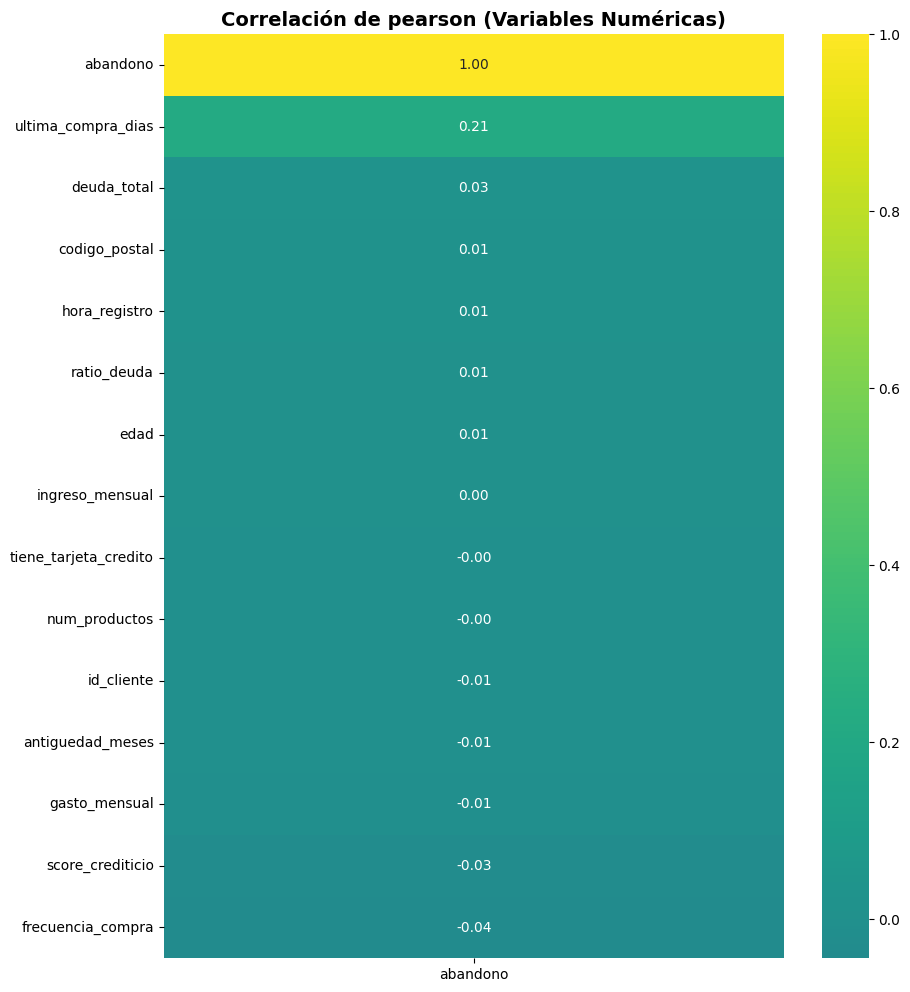

In [62]:
def analizar_correlacion_robusta(df_sucio, x_metodo = 'pearson'):
    """
    ANÁLISIS DE CORRELACIÓN DE SPEARMAN ()

    Este bloque identifica las relaciones en el dataset 'df' ignorando
    automáticamente las columnas de texto que causarían errores de conversión.

   Usamos la correlacion de Spearman porque es ideal para
       detectar tendencias en datos que aún tienen valores negativos o
       extremadamente altos (outliers).

    """
    # 1. Calculamos la matriz de correlación de Spearman
    # Agregamos numeric_only=True para evitar el error con las fechas y textos
    matriz_spearman = df_sucio.corr(
        method=x_metodo,
        numeric_only=True
    )[['abandono']].sort_values(by='abandono', ascending=False)

    # 2. Configuración visual
    plt.figure(figsize=(10, 12))

    # 3. Generamos el Heatmap
    sns.heatmap(matriz_spearman, annot=True, cmap='viridis', fmt=".2f", center=0)

    plt.title(f"Correlación de {x_metodo} (Variables Numéricas)", fontsize=14, fontweight='bold')
    plt.show()

# Ejecutamos sobre el dataset original
analizar_correlacion_robusta(df, x_metodo = 'pearson')

Tras analizar ambas correlaciones basadas en la robustez de Spearman para el diagnóstico inicial de los datos crudos y la precisión lineal de Pearson para el conjunto de datos procesado, encontramos que no hay una razón exacta y simplista para entender el abandono del servicio debido a que los coeficientes obtenidos son cercanos a cero (rango de 0.01 a -0.02). Esta falta de correlación lineal fuerte se explica por los siguientes motivos técnicos y de negocio:

1) Multicausalidad del Churn: El abandono no está determinado por una sola variable aislada, como la deuda o la edad, sino por una combinación compleja de factores que no se manifiestan en una relación proporcional directa.

2) Efecto de la Limpieza de Datos: Aunque el Winsorizer y la imputación por media eliminaron el ruido de los valores extremos y nulos, también pudieron suavizar señales de comportamiento críticas presentes en los extremos de la distribución.

3) Relaciones No Lineales: La debilidad de los coeficientes sugiere que existen patrones no lineales o interacciones entre variables (por ejemplo, clientes con alto gasto pero baja antigüedad) que las métricas tradicionales de correlación no logran capturar.

4) Necesidad de Modelamiento Avanzado: Este hallazgo valida la necesidad de avanzar hacia modelos de Machine Learning (como árboles de decisión o bosques aleatorios), los cuales son capaces de detectar reglas de decisión complejas donde la estadística descriptiva tradicional no encuentra una señal clara.

En conclusión: Lejos de ser un error en el procesamiento, este resultado demuestra que el problema del abandono en la empresa es un fenómeno sofisticado. El valor de nuestro trabajo radica en haber limpiado el ruido técnico para confirmar que la estrategia de retención debe basarse en perfiles predictivos integrales y no en métricas aisladas.

# Revision CSV nuevo

In [63]:
csv_nuevo = pd.read_csv('dataset_clientes_limpio.csv')
csv_nuevo

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,ratio_deuda,...,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,uso_app,tipo_plan,riesgo_financiero,abandono
0,0.818182,0.638167,0.750001,0.648654,0.069273,0.886792,0.277778,1.000000,0.50,0.350003,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
1,0.545455,1.000000,0.328167,0.344409,0.426879,0.547170,0.388889,0.878049,0.75,0.082658,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,0
2,0.490909,0.496368,0.474789,1.000000,1.000000,0.000000,0.611111,0.649390,0.75,0.371217,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,0.0,0
3,0.600000,0.059194,0.535374,0.851296,0.031360,0.000000,0.111111,0.445122,0.25,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1
4,0.181818,0.420252,0.683403,0.350711,0.107477,0.066038,0.222222,0.804878,0.50,0.270779,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.345455,0.827946,0.454569,0.373476,0.900207,0.792453,0.555556,0.957317,0.50,0.154541,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1
19996,0.509091,0.716304,0.196729,0.448783,0.451902,0.481132,0.388889,0.966463,0.50,0.218873,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1
19997,0.400000,0.496368,0.571591,0.813018,0.710751,0.896226,0.222222,0.423780,1.00,0.371217,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0
19998,1.000000,0.310641,0.203465,0.574915,0.475218,0.915094,0.388889,0.679878,0.25,0.497706,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0


In [64]:
"""
PROPÓSITO:
Generar el archivo de dependencias 'requirements.txt' que documenta las versiones
exactas de todas las librerías utilizadas en este proyecto (Pandas, Scikit-Learn, etc.).

JUSTIFICACIÓN TÉCNICA (REPRODUCIBILIDAD):
Aunque el desarrollo se realiza en Google Colab, este comando permite exportar
el estado del entorno de ejecución. Esto garantiza que cualquier usuario pueda
replicar este análisis en un entorno local (Conda o venv) instalando las mismas
versiones, evitando errores de compatibilidad y asegurando la integridad de los
resultados del Pipeline de transformación.

"""

!pip freeze > requirements.txt
